# Analisis Global Commodity Shock

**Dampak Konflik Iran-Amerika Serikat 2026 terhadap Komoditas Global dan Consumer Confidence Indonesia**

Notebook ini menganalisis penyimpangan harga Brent oil, natural gas, dan gold terhadap baseline historis. Model utama yang digunakan untuk laporan akhir adalah **ARIMA time series model**.

**Anggota Kelompok:**

| Nama | NIM |
|---|---|
| DANAR FATHURAHMAN | 24/538200/PA/22828 |
| FAHMI ABDILLAH ZAIN | 24/539422/PA/22904 |
| MUHAMMAD DHAFIN ALFEIZAR GANDHANG | 24/539735/PA/22916 |
| SATYA WIRA PRAMUDITA | 24/543649/PA/23102 |
| AJIE ARMANSYAH SUNARYO | 24/545286/PA/23170 |

## 1. Pendahuluan

Konflik geopolitik dapat memengaruhi harga komoditas global, terutama energi dan aset safe-haven. Penelitian ini menggunakan Brent oil, natural gas, gold, dan Indonesia CCI untuk melihat indikasi shock pasar serta hubungannya dengan sentimen konsumen Indonesia.

**Pertanyaan penelitian:** Seberapa besar komoditas global menyimpang dari baseline historis selama periode konflik Iran-Amerika Serikat 2026, dan bagaimana hubungannya dengan Consumer Confidence Indonesia?

**Relevansi SDG:** Analisis ini berkaitan dengan **SDG 8: Decent Work and Economic Growth**, karena perubahan harga komoditas dapat memengaruhi inflasi, daya beli, dan ekspektasi rumah tangga.

**Catatan interpretasi:** Prediction gap menunjukkan penyimpangan dari baseline, bukan bukti bahwa konflik menjadi satu-satunya penyebab.

**Catatan data:** `IndonesiaCCI.csv` digunakan sebagai proxy CCI yang diterima dalam proyek ini, sehingga interpretasi tetap perlu dilakukan hati-hati.

## 2. Import Library

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'

COLOR_MAP = {
    'brent': '#0072B2',
    'gas': '#E69F00',
    'gold': '#F0E442',
    'cci': '#009E73',
    'baseline': '#666666',
    'shock': '#D55E00',
    'conflict': '#CC6677',
    'zero': '#222222',
}

INDICATOR_COLOR_MAP = {
    'brent_price': COLOR_MAP['brent'],
    'gas_price': COLOR_MAP['gas'],
    'gold_price': COLOR_MAP['gold'],
    'cci': COLOR_MAP['cci'],
}

GAP_COLOR_MAP = {
    'Brent oil': COLOR_MAP['brent'],
    'Natural gas': COLOR_MAP['gas'],
    'Gold': COLOR_MAP['gold'],
}


## 3. Folder Proyek

In [2]:
BASE_DIR = Path('.')
DATA_DIR = BASE_DIR / 'data'
PROCESSED_DATA_DIR = DATA_DIR / 'processed'
FIGURES_DIR = BASE_DIR / 'figures'
OUTPUTS_DIR = BASE_DIR / 'outputs'

for directory in [PROCESSED_DATA_DIR, FIGURES_DIR, OUTPUTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

START_DATE = pd.Timestamp('2000-01-01')
TRAIN_END_DATE = pd.Timestamp('2025-12-01')
ANALYSIS_START_DATE = pd.Timestamp('2026-01-01')
CONFLICT_FOCUS_DATE = pd.Timestamp('2026-02-01')


## 4. Load Dataset

Setiap dataset dimuat dari file mentah. Karena format tanggal berbeda, data dibersihkan terlebih dahulu sebelum digabungkan.

In [3]:
brent_raw = pd.read_csv(DATA_DIR / 'Brent.csv')
gas_raw = pd.read_csv(DATA_DIR / 'NaturalGas.csv')
gold_raw = pd.read_csv(DATA_DIR / 'Gold.csv')
cci_raw = pd.read_csv(DATA_DIR / 'IndonesiaCCI.csv')

raw_shapes = pd.DataFrame({
    'dataset': ['Brent', 'Natural Gas', 'Gold', 'Indonesia CCI proxy'],
    'rows': [len(brent_raw), len(gas_raw), len(gold_raw), len(cci_raw)],
    'columns': [brent_raw.shape[1], gas_raw.shape[1], gold_raw.shape[1], cci_raw.shape[1]],
})
display(raw_shapes)


,dataset,rows,columns
0,Brent,468,2
1,Natural Gas,353,2
2,Gold,2321,2
3,Indonesia CCI proxy,388,34


## 5. Data Cleaning

Kolom tanggal diubah menjadi format bulanan dengan tanggal awal bulan. Semua nilai indikator juga dikonversi menjadi numerik agar siap dianalisis.

In [4]:
def clean_price_data(raw_data, date_column, value_column, final_value_column):
    data = raw_data[[date_column, value_column]].copy()
    data = data.rename(columns={date_column: 'date', value_column: final_value_column})

    data['date'] = pd.to_datetime(data['date'], errors='coerce')
    data['date'] = data['date'].dt.to_period('M').dt.to_timestamp()
    data[final_value_column] = pd.to_numeric(data[final_value_column], errors='coerce')

    data = data.dropna(subset=['date', final_value_column])
    data = data.groupby('date', as_index=False)[final_value_column].mean()
    data = data.sort_values('date').reset_index(drop=True)

    return data

brent_data = clean_price_data(brent_raw, 'Date', 'Price', 'brent_price')
gas_data = clean_price_data(gas_raw, 'Month', 'Price', 'gas_price')
gold_data = clean_price_data(gold_raw, 'Date', 'Price', 'gold_price')

cci_data = cci_raw[['TIME_PERIOD', 'OBS_VALUE']].copy()
cci_data = cci_data.rename(columns={'TIME_PERIOD': 'date', 'OBS_VALUE': 'cci'})
cci_data['date'] = pd.to_datetime(cci_data['date'], errors='coerce')
cci_data['date'] = cci_data['date'].dt.to_period('M').dt.to_timestamp()
cci_data['cci'] = pd.to_numeric(cci_data['cci'], errors='coerce')
cci_data = cci_data.dropna(subset=['date', 'cci'])
cci_data = cci_data.groupby('date', as_index=False)['cci'].mean()
cci_data = cci_data.sort_values('date').reset_index(drop=True)


In [5]:
def summarize_clean_data(name, data, value_column):
    return {
        'dataset': name,
        'rows': len(data),
        'start_date': data['date'].min(),
        'end_date': data['date'].max(),
        'missing_values': data[value_column].isna().sum(),
    }

clean_summary = pd.DataFrame([
    summarize_clean_data('Brent oil', brent_data, 'brent_price'),
    summarize_clean_data('Henry Hub natural gas', gas_data, 'gas_price'),
    summarize_clean_data('Gold', gold_data, 'gold_price'),
    summarize_clean_data('Indonesia CCI proxy', cci_data, 'cci'),
])

display(clean_summary)


,dataset,rows,start_date,end_date,missing_values
0,Brent oil,468,1987-05-01,2026-04-01,0
1,Henry Hub natural gas,353,1997-01-01,2026-05-01,0
2,Gold,2321,1833-01-01,2026-05-01,0
3,Indonesia CCI proxy,388,1994-01-01,2026-04-01,0


## 6. Merge Dataset

Semua dataset digabung berdasarkan kolom `date` bulanan. Inner join digunakan agar hanya bulan yang tersedia di semua dataset yang masuk ke analisis.

In [6]:
analysis_data = brent_data.merge(gas_data, on='date', how='inner')
analysis_data = analysis_data.merge(gold_data, on='date', how='inner')
analysis_data = analysis_data.merge(cci_data, on='date', how='inner')
analysis_data = analysis_data[analysis_data['date'] >= START_DATE].copy()
analysis_data = analysis_data.sort_values('date').reset_index(drop=True)

print(f'Merged date range: {analysis_data["date"].min().date()} to {analysis_data["date"].max().date()}')
print(f'Merged rows: {len(analysis_data)}')
display(analysis_data.head())
display(analysis_data.tail())


Merged date range: 2000-01-01 to 2026-04-01
Merged rows: 316


,date,brent_price,gas_price,gold_price,cci
0,2000-01-01,25.51,2.42,284.32,101.99
1,2000-02-01,27.78,2.66,299.86,102.18
2,2000-03-01,27.49,2.79,286.39,102.18
3,2000-04-01,22.76,3.04,279.69,101.99
4,2000-05-01,27.74,3.59,275.19,101.67


,date,brent_price,gas_price,gold_price,cci
311,2025-12-01,62.54,4.26,"4,309.23",101.09
312,2026-01-01,66.60,7.72,"4,752.75",101.06
313,2026-02-01,70.89,3.62,"5,019.97",100.93
314,2026-03-01,103.13,3.04,"4,855.54",100.73
315,2026-04-01,117.29,2.77,"4,721.42",100.52


In [7]:
missing_summary = analysis_data.isna().sum().reset_index()
missing_summary.columns = ['column', 'missing_count']
display(missing_summary)


,column,missing_count
0,date,0
1,brent_price,0
2,gas_price,0
3,gold_price,0
4,cci,0


## 7. Exploratory Data Analysis

Bagian ini melihat pola umum Brent oil, natural gas, gold, dan Indonesia CCI sebelum masuk ke model. Grafik historis dipakai untuk memahami konteks pergerakan data.

In [8]:
display(analysis_data[['brent_price', 'gas_price', 'gold_price', 'cci']].describe().T)


,count,mean,std,min,25%,50%,75%,max
brent_price,316.00,67.07,28.27,18.38,44.90,65.72,84.69,132.72
gas_price,316.00,4.31,2.13,1.49,2.81,3.71,5.39,13.42
gold_price,316.00,"1,270.16",835.79,260.48,623.53,"1,243.26","1,681.38","5,019.97"
cci,316.00,99.75,1.50,94.28,99.08,99.92,100.73,103.13


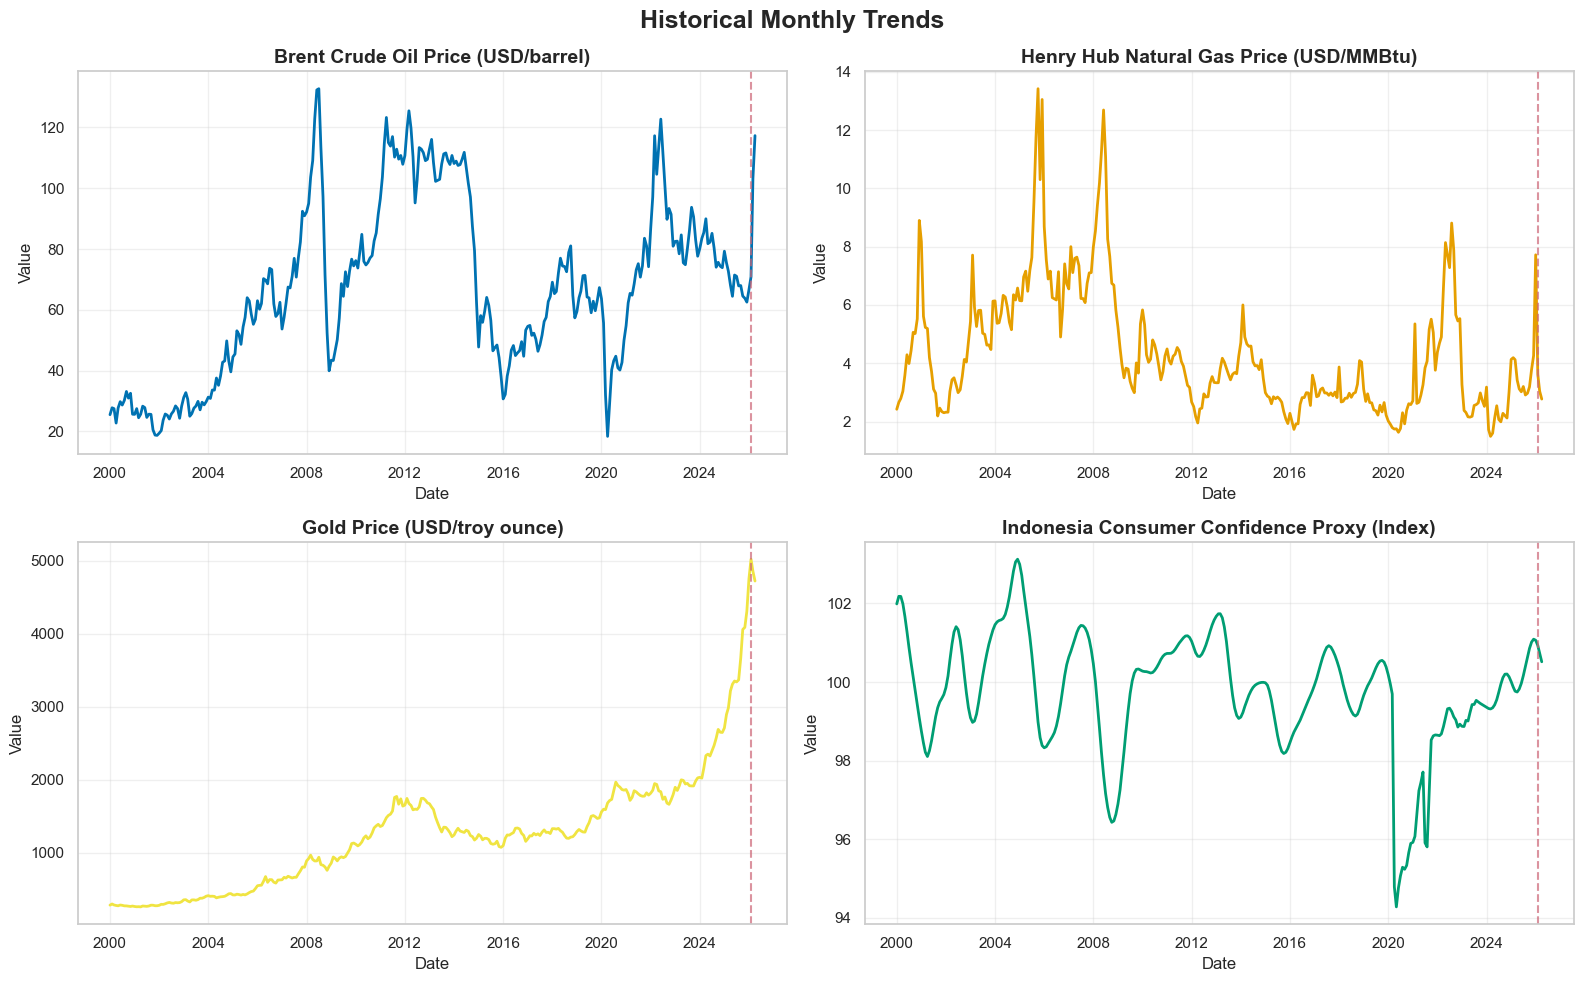

In [9]:
trend_columns = {
    'brent_price': 'Brent Crude Oil Price (USD/barrel)',
    'gas_price': 'Henry Hub Natural Gas Price (USD/MMBtu)',
    'gold_price': 'Gold Price (USD/troy ounce)',
    'cci': 'Indonesia Consumer Confidence Proxy (Index)',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for axis, (column, title) in zip(axes, trend_columns.items()):
    axis.plot(analysis_data['date'], analysis_data[column], linewidth=2, color=INDICATOR_COLOR_MAP[column])
    axis.axvline(CONFLICT_FOCUS_DATE, color=COLOR_MAP['conflict'], linestyle='--', linewidth=1.5, alpha=0.7)
    axis.set_title(title, fontsize=14, fontweight='bold')
    axis.set_xlabel('Date')
    axis.set_ylabel('Value')
    axis.grid(alpha=0.3)

fig.suptitle('Historical Monthly Trends', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'historical_trends.png', dpi=300, bbox_inches='tight')
plt.show()


### Zoom 2024-2026

Zoom periode 2024-2026 digunakan agar perubahan menjelang dan selama periode konflik 2026 lebih mudah dibaca.

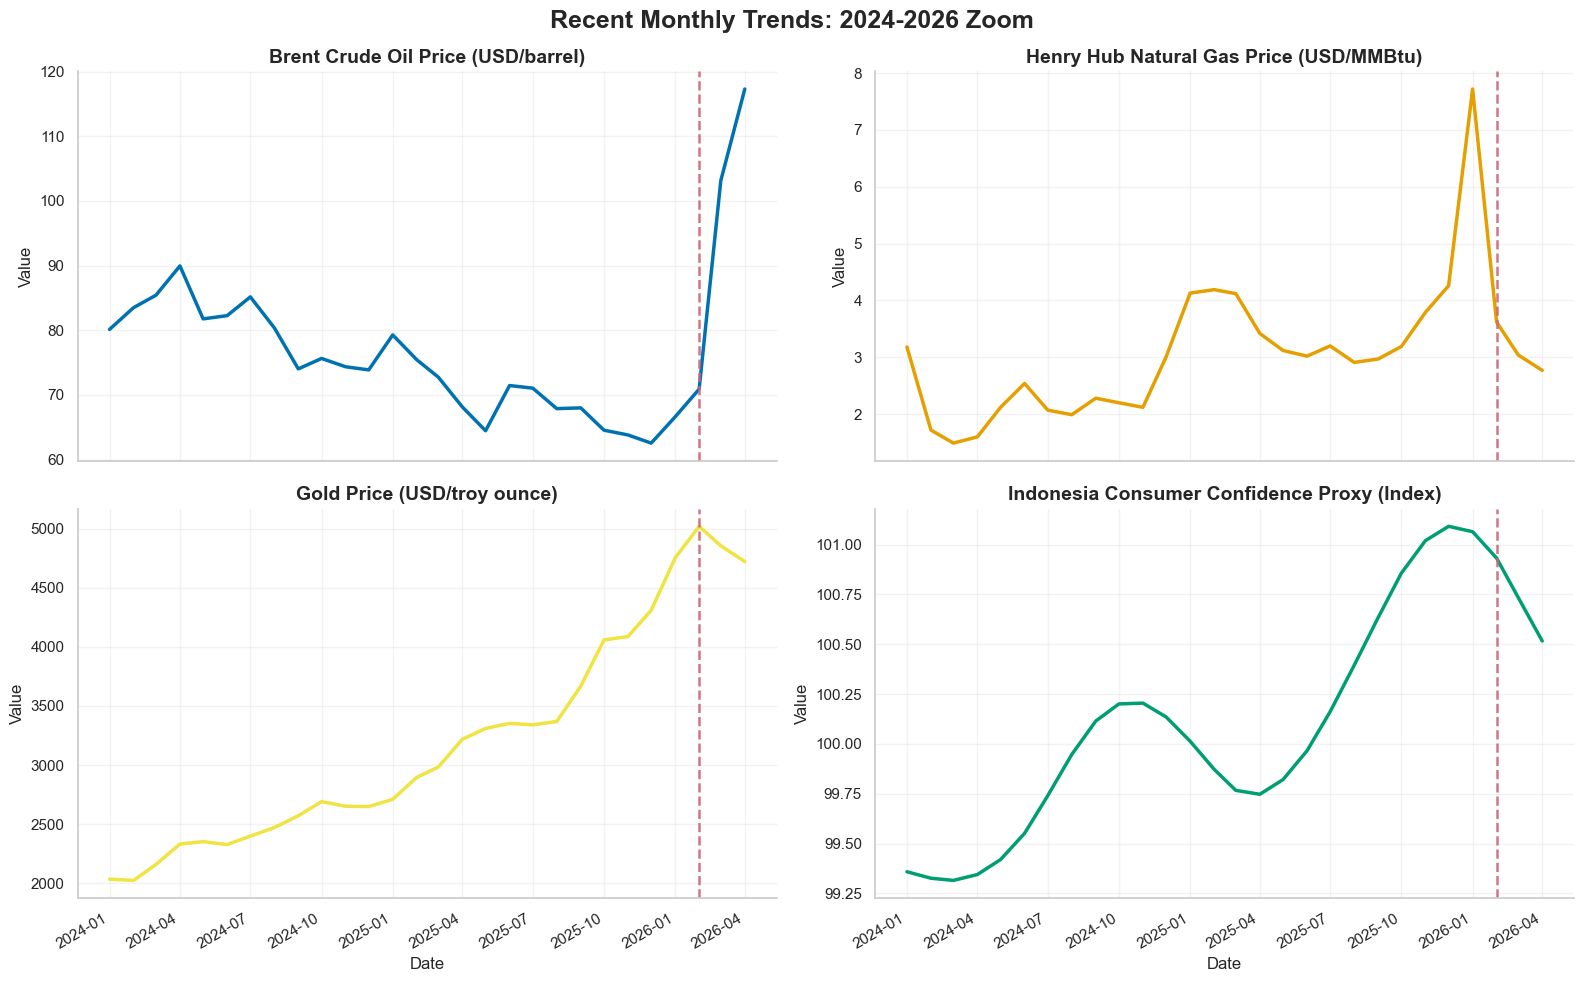

In [10]:
ZOOM_START_DATE = pd.Timestamp('2024-01-01')
ZOOM_END_DATE = pd.Timestamp('2026-12-01')
zoom_data = analysis_data[(analysis_data['date'] >= ZOOM_START_DATE) & (analysis_data['date'] <= ZOOM_END_DATE)].copy()
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for axis, (column, title) in zip(axes, trend_columns.items()):
    axis.plot(zoom_data['date'], zoom_data[column], linewidth=2.5, color=INDICATOR_COLOR_MAP[column])
    axis.axvline(CONFLICT_FOCUS_DATE, color=COLOR_MAP['conflict'], linestyle='--', linewidth=1.8, alpha=0.9)
    axis.set_title(title, fontsize=14, fontweight='bold')
    axis.set_xlabel('Date')
    axis.set_ylabel('Value')
    axis.grid(alpha=0.25)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)

fig.suptitle('Recent Monthly Trends: 2024-2026 Zoom', fontsize=18, fontweight='bold')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'historical_trends_2024_2026.png', dpi=300, bbox_inches='tight')
plt.show()


## 8. Feature Engineering

`month_index` dibuat sebagai penanda urutan waktu. Persentase perubahan bulanan juga dihitung untuk kebutuhan correlation analysis.

In [11]:
analysis_data['month_index'] = np.arange(len(analysis_data))
analysis_data['year'] = analysis_data['date'].dt.year
analysis_data['month'] = analysis_data['date'].dt.month

for column in ['brent_price', 'gas_price', 'gold_price', 'cci']:
    change_column = column.replace('_price', '') + '_change_percent'
    analysis_data[change_column] = analysis_data[column].pct_change() * 100

display(analysis_data[['date', 'month_index', 'year', 'month', 'brent_change_percent', 'gas_change_percent', 'gold_change_percent', 'cci_change_percent']].head())


,date,month_index,year,month,brent_change_percent,gas_change_percent,gold_change_percent,cci_change_percent
0,2000-01-01,0,2000,1,NaN,NaN,NaN,NaN
1,2000-02-01,1,2000,2,8.90,9.92,5.47,0.19
2,2000-03-01,2,2000,3,-1.04,4.89,-4.49,-0.00
3,2000-04-01,3,2000,4,-17.21,8.96,-2.34,-0.18
4,2000-05-01,4,2000,5,21.88,18.09,-1.61,-0.31


---

# Metode Lama (Sebelum Evaluasi)

Kami menggunakan Linear Regression di awal sebelum ada evaluasi. Untuk versi terbaru (menggunakan model time-series ARIMA) dapat dilihat di nomor 16.

---

## 9. Tahap Awal: Linear Regression Baseline

Bagian ini dipertahankan sebagai baseline awal dari notebook. Hasil utama untuk laporan akhir menggunakan ARIMA karena data berbentuk time series bulanan.

In [12]:
def train_baseline_model(data, target_column, prediction_column):
    train_data = data[data['date'] <= TRAIN_END_DATE].copy()

    X_train = train_data[['month_index']]
    y_train = train_data[target_column]

    model = LinearRegression()
    model.fit(X_train, y_train)

    data[prediction_column] = model.predict(data[['month_index']])
    train_prediction = model.predict(X_train)

    metrics = {
        'target': target_column,
        'MAE': mean_absolute_error(y_train, train_prediction),
        'RMSE': np.sqrt(mean_squared_error(y_train, train_prediction)),
        'R2 Score': r2_score(y_train, train_prediction),
    }

    return data, model, metrics

model_results = {}
metrics_list = []

analysis_data, brent_model, brent_metrics = train_baseline_model(analysis_data, 'brent_price', 'brent_prediction')
analysis_data, gas_model, gas_metrics = train_baseline_model(analysis_data, 'gas_price', 'gas_prediction')
analysis_data, gold_model, gold_metrics = train_baseline_model(analysis_data, 'gold_price', 'gold_prediction')

model_results['brent'] = brent_model
model_results['gas'] = gas_model
model_results['gold'] = gold_model
metrics_list.extend([brent_metrics, gas_metrics, gold_metrics])

model_metrics = pd.DataFrame(metrics_list)
display(model_metrics)
model_metrics.to_csv(OUTPUTS_DIR / 'model_metrics.csv', index=False)


,target,MAE,RMSE,R2 Score
0,brent_price,21.03,25.68,0.17
1,gas_price,1.40,1.92,0.19
2,gold_price,228.96,341.54,0.78


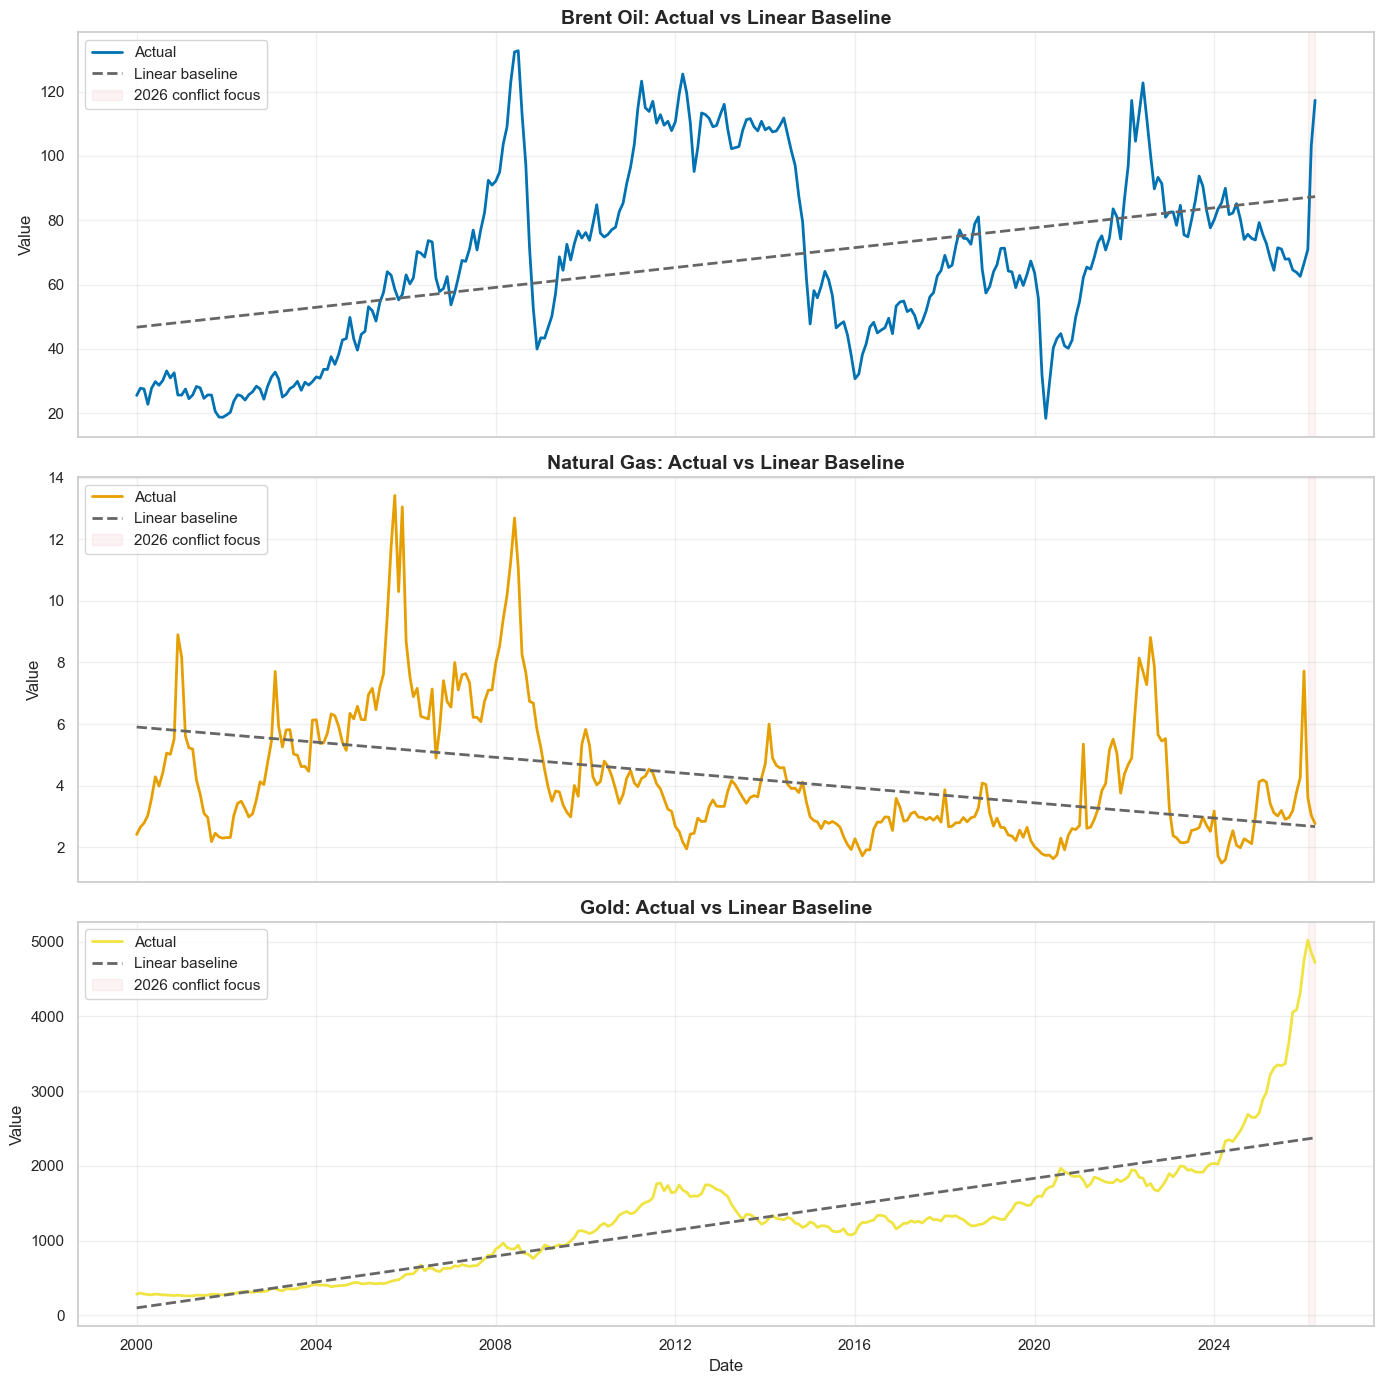

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
actual_prediction_pairs = [
    ('brent_price', 'brent_prediction', 'Brent Oil: Actual vs Linear Baseline'),
    ('gas_price', 'gas_prediction', 'Natural Gas: Actual vs Linear Baseline'),
    ('gold_price', 'gold_prediction', 'Gold: Actual vs Linear Baseline'),
]

for axis, (actual_column, prediction_column, title) in zip(axes, actual_prediction_pairs):
    axis.plot(analysis_data['date'], analysis_data[actual_column], label='Actual', linewidth=2, color=INDICATOR_COLOR_MAP[actual_column])
    axis.plot(analysis_data['date'], analysis_data[prediction_column], label='Linear baseline', linestyle='--', linewidth=2, color=COLOR_MAP['baseline'])
    axis.axvspan(CONFLICT_FOCUS_DATE, analysis_data['date'].max(), color=COLOR_MAP['conflict'], alpha=0.08, label='2026 conflict focus')
    axis.set_title(title, fontsize=14, fontweight='bold')
    axis.set_ylabel('Value')
    axis.grid(alpha=0.3)
    axis.legend(loc='upper left')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()


### Zoom Actual vs Predicted: 2024-2026

Grafik zoom ini membantu melihat gap pada periode terbaru dengan lebih jelas.

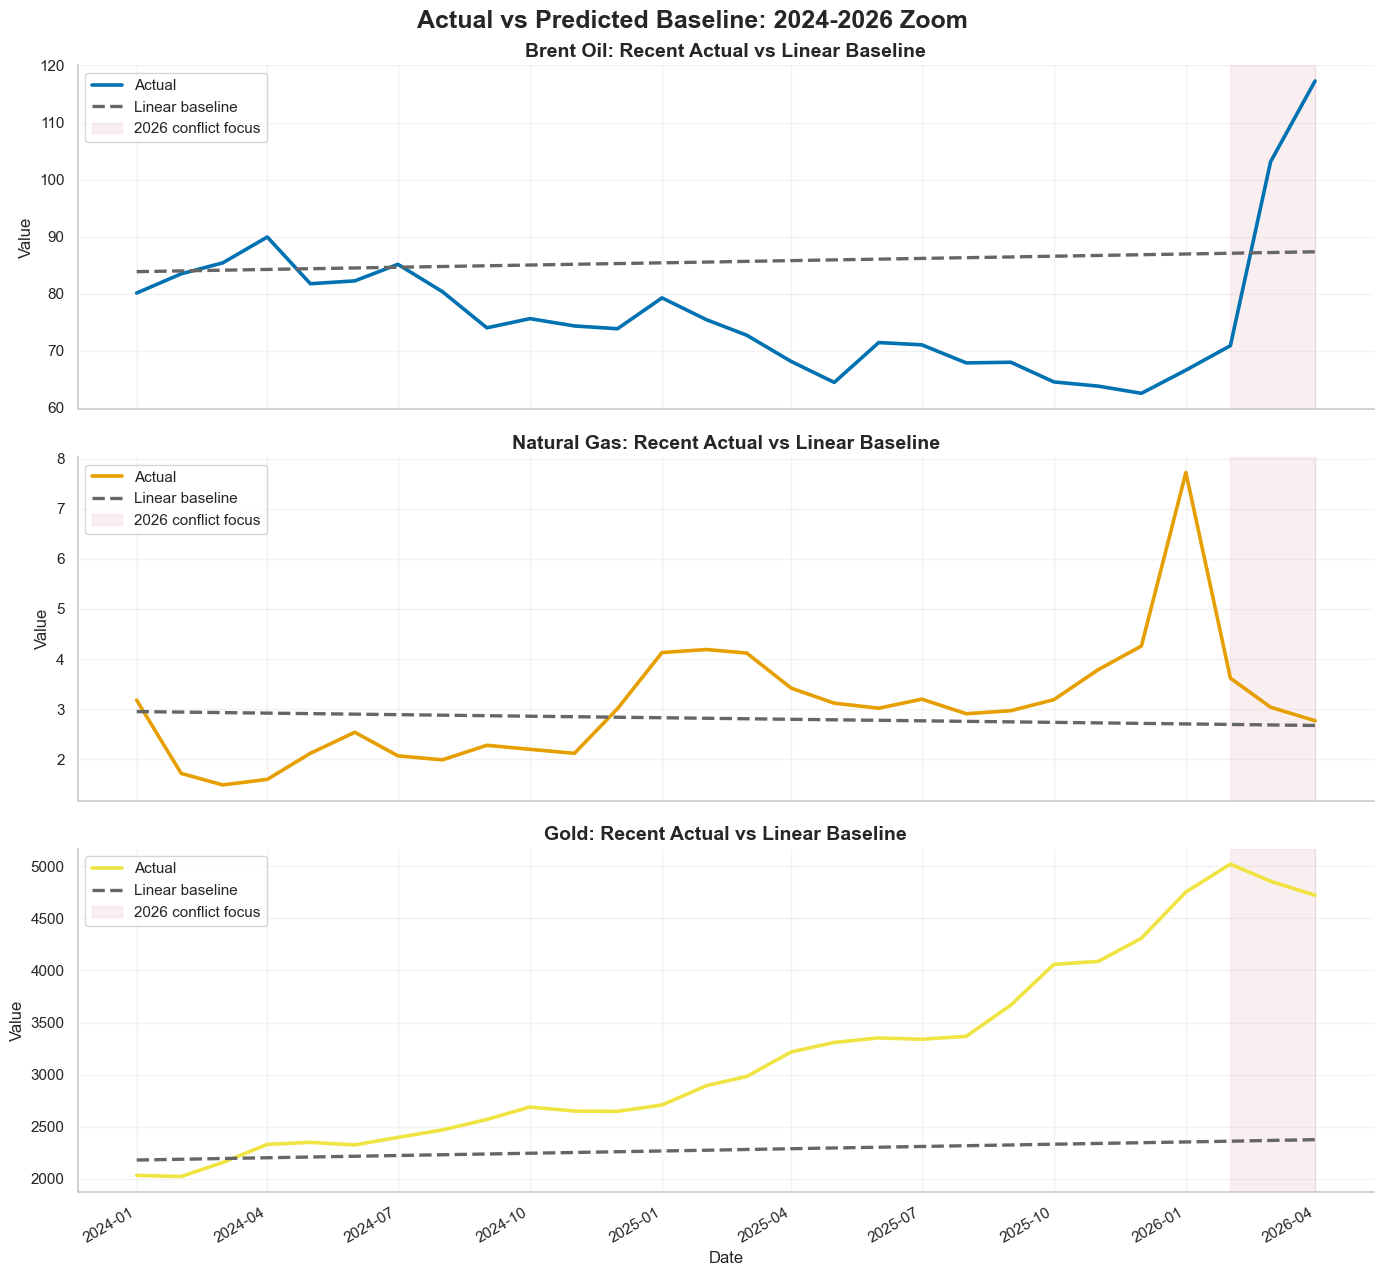

In [14]:
zoom_prediction_data = analysis_data[(analysis_data['date'] >= ZOOM_START_DATE) & (analysis_data['date'] <= ZOOM_END_DATE)].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
zoom_actual_prediction_pairs = [
    ('brent_price', 'brent_prediction', 'Brent Oil: Recent Actual vs Linear Baseline'),
    ('gas_price', 'gas_prediction', 'Natural Gas: Recent Actual vs Linear Baseline'),
    ('gold_price', 'gold_prediction', 'Gold: Recent Actual vs Linear Baseline'),
]

baseline_color = COLOR_MAP['baseline']

for axis, (actual_column, prediction_column, title) in zip(axes, zoom_actual_prediction_pairs):
    axis.plot(zoom_prediction_data['date'], zoom_prediction_data[actual_column], label='Actual', linewidth=2.6, color=INDICATOR_COLOR_MAP[actual_column])
    axis.plot(zoom_prediction_data['date'], zoom_prediction_data[prediction_column], label='Linear baseline', linestyle='--', linewidth=2.4, color=baseline_color)
    axis.axvspan(CONFLICT_FOCUS_DATE, zoom_prediction_data['date'].max(), color=COLOR_MAP['conflict'], alpha=0.10, label='2026 conflict focus')
    axis.set_title(title, fontsize=14, fontweight='bold')
    axis.set_ylabel('Value')
    axis.grid(alpha=0.25)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.legend(loc='upper left', frameon=True)

axes[-1].set_xlabel('Date')
fig.suptitle('Actual vs Predicted Baseline: 2024-2026 Zoom', fontsize=18, fontweight='bold')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'actual_vs_predicted_2024_2026.png', dpi=300, bbox_inches='tight')
plt.show()


## 10. Prediction Gap Analysis

Rumus gap adalah `actual - predicted`. Gap positif berarti nilai aktual lebih tinggi dari baseline, sedangkan gap negatif berarti lebih rendah dari baseline.

In [15]:
commodity_columns = {
    'brent': ('brent_price', 'brent_prediction'),
    'gas': ('gas_price', 'gas_prediction'),
    'gold': ('gold_price', 'gold_prediction'),
}

for commodity, (actual_column, prediction_column) in commodity_columns.items():
    gap_column = f'{commodity}_gap'
    gap_percent_column = f'{commodity}_gap_percent'

    analysis_data[gap_column] = analysis_data[actual_column] - analysis_data[prediction_column]
    analysis_data[gap_percent_column] = (analysis_data[gap_column] / analysis_data[prediction_column]) * 100

shock_2026 = analysis_data[analysis_data['date'] >= ANALYSIS_START_DATE].copy()
gap_columns = [
    'date',
    'brent_price', 'brent_prediction', 'brent_gap', 'brent_gap_percent',
    'gas_price', 'gas_prediction', 'gas_gap', 'gas_gap_percent',
    'gold_price', 'gold_prediction', 'gold_gap', 'gold_gap_percent',
    'cci', 'cci_change_percent',
]
display(shock_2026[gap_columns])


,date,brent_price,brent_prediction,brent_gap,brent_gap_percent,gas_price,gas_prediction,gas_gap,gas_gap_percent,gold_price,gold_prediction,gold_gap,gold_gap_percent,cci,cci_change_percent
312,2026-01-01,66.60,86.96,-20.36,-23.41,7.72,2.71,5.01,185.23,"4,752.75","2,354.80","2,397.95",101.83,101.06,-0.03
313,2026-02-01,70.89,87.09,-16.20,-18.60,3.62,2.70,0.92,34.26,"5,019.97","2,362.02","2,657.95",112.53,100.93,-0.13
314,2026-03-01,103.13,87.22,15.91,18.24,3.04,2.69,0.35,13.18,"4,855.54","2,369.24","2,486.30",104.94,100.73,-0.20
315,2026-04-01,117.29,87.35,29.94,34.28,2.77,2.68,0.09,3.52,"4,721.42","2,376.47","2,344.95",98.67,100.52,-0.22


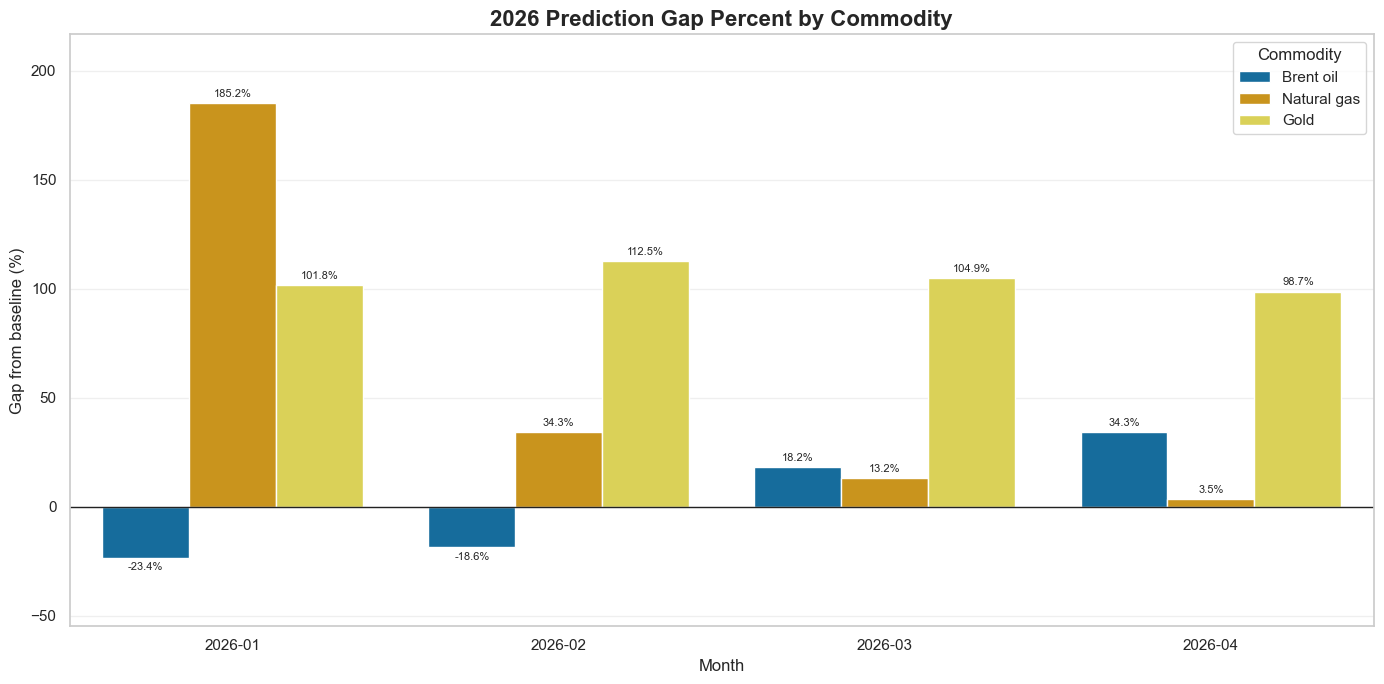

In [16]:
gap_plot_data = shock_2026[['date', 'brent_gap_percent', 'gas_gap_percent', 'gold_gap_percent']].melt(
    id_vars='date',
    var_name='commodity',
    value_name='gap_percent',
)
gap_plot_data['commodity'] = gap_plot_data['commodity'].map({
    'brent_gap_percent': 'Brent oil',
    'gas_gap_percent': 'Natural gas',
    'gold_gap_percent': 'Gold',
})

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=gap_plot_data, x='date', y='gap_percent', hue='commodity', palette=GAP_COLOR_MAP)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8)

plt.axhline(0, color=COLOR_MAP['zero'], linewidth=1)
plt.title('2026 Prediction Gap Percent by Commodity', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Gap from baseline (%)')
plt.xticks(
    ticks=range(len(shock_2026)),
    labels=shock_2026['date'].dt.strftime('%Y-%m'),
    rotation=0,
)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Commodity')
plt.margins(y=0.15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'prediction_gap_percent.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Global Commodity Shock Index

Shock index dihitung dari rata-rata gap percentage Brent oil, natural gas, dan gold. Indeks ini dipakai untuk merangkum tekanan komoditas global dalam satu nilai.

In [17]:
gap_percent_columns = ['brent_gap_percent', 'gas_gap_percent', 'gold_gap_percent']
analysis_data['global_shock_index'] = analysis_data[gap_percent_columns].mean(axis=1)
analysis_data['brent_only_shock_index'] = analysis_data['brent_gap_percent']
shock_2026 = analysis_data[analysis_data['date'] >= ANALYSIS_START_DATE].copy()

display(shock_2026[['date', 'brent_gap_percent', 'gas_gap_percent', 'gold_gap_percent', 'global_shock_index', 'brent_only_shock_index', 'cci_change_percent']])


,date,brent_gap_percent,gas_gap_percent,gold_gap_percent,global_shock_index,brent_only_shock_index,cci_change_percent
312,2026-01-01,-23.41,185.23,101.83,87.88,-23.41,-0.03
313,2026-02-01,-18.60,34.26,112.53,42.73,-18.60,-0.13
314,2026-03-01,18.24,13.18,104.94,45.45,18.24,-0.20
315,2026-04-01,34.28,3.52,98.67,45.49,34.28,-0.22


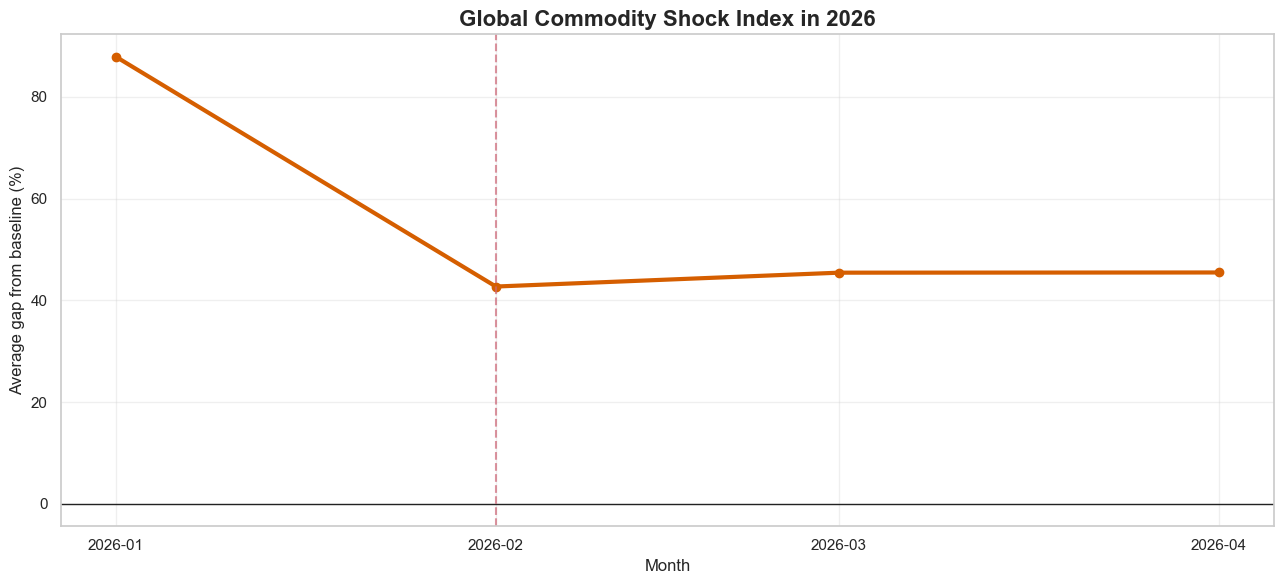

In [18]:
plt.figure(figsize=(13, 6))
plt.plot(shock_2026['date'], shock_2026['global_shock_index'], marker='o', linewidth=3, color=COLOR_MAP['shock'])
plt.axhline(0, color=COLOR_MAP['zero'], linewidth=1)
plt.axvline(CONFLICT_FOCUS_DATE, color=COLOR_MAP['conflict'], linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('Global Commodity Shock Index in 2026', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average gap from baseline (%)')
plt.xticks(shock_2026['date'], shock_2026['date'].dt.strftime('%Y-%m'))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'global_commodity_shock_index.png', dpi=300, bbox_inches='tight')
plt.show()


### Brent Oil Only Shock Index

Indeks ini hanya memakai Brent oil, sehingga nilainya sama dengan `brent_gap_percent`. Grafik ini berguna karena oil menjadi indikator energi utama.

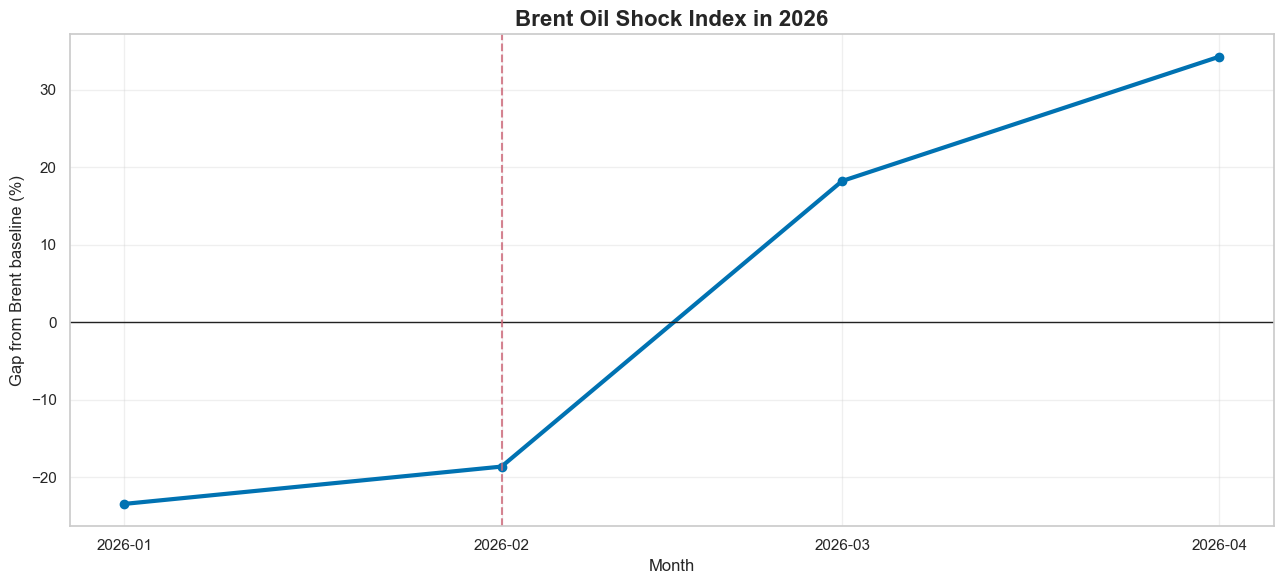

In [19]:
plt.figure(figsize=(13, 6))
plt.plot(shock_2026['date'], shock_2026['brent_only_shock_index'], marker='o', linewidth=3, color=COLOR_MAP['brent'])
plt.axhline(0, color=COLOR_MAP['zero'], linewidth=1)
plt.axvline(CONFLICT_FOCUS_DATE, color=COLOR_MAP['conflict'], linestyle='--', linewidth=1.5, alpha=0.8)
plt.title('Brent Oil Shock Index in 2026', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Gap from Brent baseline (%)')
plt.xticks(shock_2026['date'], shock_2026['date'].dt.strftime('%Y-%m'))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'brent_only_shock_index.png', dpi=300, bbox_inches='tight')
plt.show()


## 12. Correlation Analysis

Correlation matrix memakai persentase perubahan bulanan, bukan harga mentah. Tujuannya agar hubungan antarvariabel tidak terlalu dipengaruhi tren jangka panjang.

,brent_change_percent,gas_change_percent,gold_change_percent,cci_change_percent
brent_change_percent,1.00,0.11,0.08,0.18
gas_change_percent,0.11,1.00,0.06,-0.02
gold_change_percent,0.08,0.06,1.00,0.02
cci_change_percent,0.18,-0.02,0.02,1.00


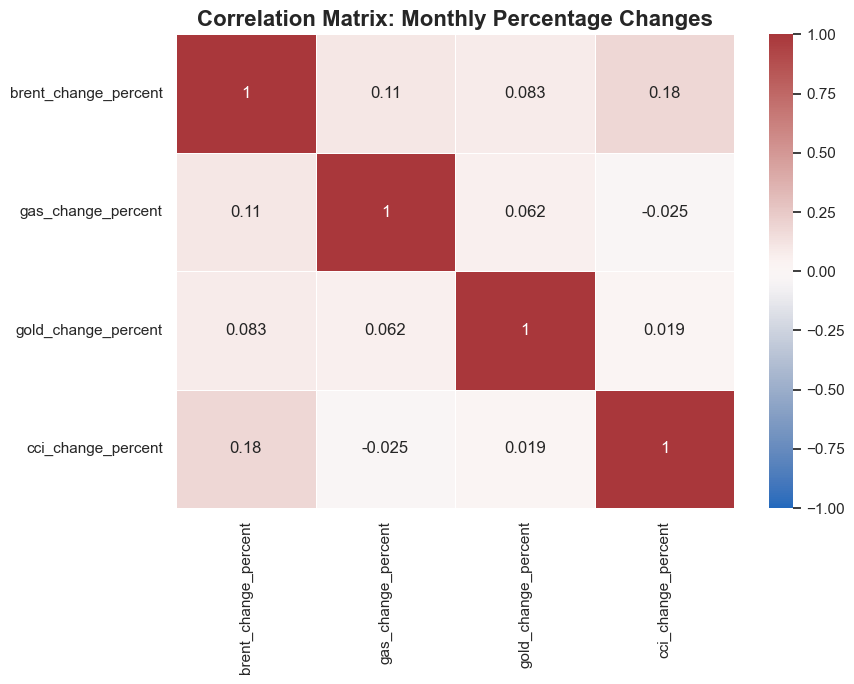

In [20]:
correlation_columns = [
    'brent_change_percent',
    'gas_change_percent',
    'gold_change_percent',
    'cci_change_percent',
]

correlation_matrix = analysis_data[correlation_columns].dropna().corr(method='pearson')
display(correlation_matrix)

plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='vlag', center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix: Monthly Percentage Changes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_matrix_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


### Standardized Brent Oil and CCI Overlay

Grafik ini membandingkan Brent oil dan Indonesia CCI setelah distandardisasi dengan z-score. Standardisasi membuat dua variabel dengan satuan berbeda bisa dilihat dalam satu grafik.

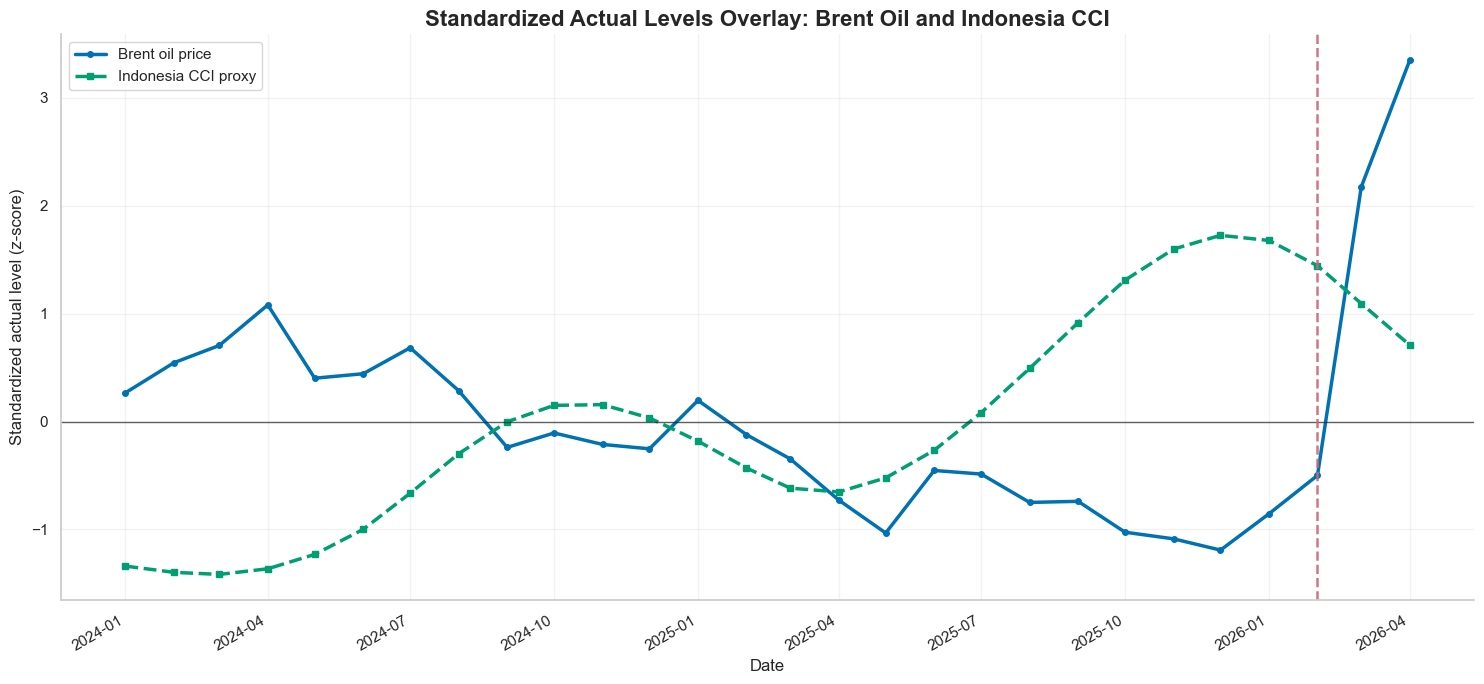

In [21]:
OIL_CCI_OVERLAY_START_DATE = pd.Timestamp('2024-01-01')

level_overlay_columns = {
    'brent_price': 'Brent oil price',
    'cci': 'Indonesia CCI proxy',
}

level_overlay_data = analysis_data[analysis_data['date'] >= OIL_CCI_OVERLAY_START_DATE][['date', *level_overlay_columns.keys()]].copy()

for column in level_overlay_columns:
    mean_value = level_overlay_data[column].mean()
    std_value = level_overlay_data[column].std()
    level_overlay_data[f'{column}_standardized'] = (level_overlay_data[column] - mean_value) / std_value

standardized_overlay_data = level_overlay_data[['date'] + [f'{column}_standardized' for column in level_overlay_columns]].melt(
    id_vars='date',
    var_name='indicator',
    value_name='standardized_value',
)
standardized_overlay_data['indicator'] = standardized_overlay_data['indicator'].replace({
    f'{column}_standardized': label for column, label in level_overlay_columns.items()
})

overlay_color_map = {
    'Brent oil price': COLOR_MAP['brent'],
    'Indonesia CCI proxy': COLOR_MAP['cci'],
}
line_styles = ['-', '--']
markers = ['o', 's']

fig, ax = plt.subplots(figsize=(15, 7))

for index, (indicator, indicator_data) in enumerate(standardized_overlay_data.groupby('indicator')):
    ax.plot(
        indicator_data['date'],
        indicator_data['standardized_value'],
        label=indicator,
        linewidth=2.5,
        linestyle=line_styles[index],
        marker=markers[index],
        markersize=4,
        color=overlay_color_map[indicator],
    )

ax.axhline(0, color=COLOR_MAP['zero'], linewidth=1, alpha=0.7)
ax.axvline(CONFLICT_FOCUS_DATE, color=COLOR_MAP['conflict'], linestyle='--', linewidth=1.8, alpha=0.9)
ax.set_title('Standardized Actual Levels Overlay: Brent Oil and Indonesia CCI', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Standardized actual level (z-score)')
ax.grid(alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', frameon=True)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'standardized_oil_cci_overlay_2024_2026.png', dpi=300, bbox_inches='tight')
plt.show()


In [22]:
shock_correlation_columns = [
    'brent_gap_percent',
    'gas_gap_percent',
    'gold_gap_percent',
    'cci_change_percent',
]

shock_correlation_matrix = shock_2026[shock_correlation_columns].dropna().corr(method='pearson')
display(shock_correlation_matrix)


,brent_gap_percent,gas_gap_percent,gold_gap_percent,cci_change_percent
brent_gap_percent,1.00,-0.73,-0.56,-0.89
gas_gap_percent,-0.73,1.00,-0.15,0.96
gold_gap_percent,-0.56,-0.15,1.00,0.12
cci_change_percent,-0.89,0.96,0.12,1.00


## 13. Save Processed Outputs

Data hasil olahan, shock gap, dan correlation matrix disimpan agar dapat digunakan kembali untuk laporan dan infographic.

In [23]:
processed_data_path = PROCESSED_DATA_DIR / 'merged_commodity_cci_data.csv'
output_data_path = OUTPUTS_DIR / 'merged_commodity_cci_data.csv'
shock_output_path = OUTPUTS_DIR / 'shock_gap_2026.csv'
correlation_output_path = OUTPUTS_DIR / 'correlation_matrix.csv'

analysis_data.to_csv(processed_data_path, index=False)
analysis_data.to_csv(output_data_path, index=False)
shock_2026.to_csv(shock_output_path, index=False)
correlation_matrix.to_csv(correlation_output_path)

print(f'Saved processed data to {processed_data_path}')
print(f'Saved merged output data to {output_data_path}')
print(f'Saved 2026 shock gap data to {shock_output_path}')
print(f'Saved correlation matrix to {correlation_output_path}')


Saved processed data to data/processed/merged_commodity_cci_data.csv
Saved merged output data to outputs/merged_commodity_cci_data.csv
Saved 2026 shock gap data to outputs/shock_gap_2026.csv
Saved correlation matrix to outputs/correlation_matrix.csv


## 14. Catatan Hasil Linear Regression

Bagian ini merangkum hasil Linear Regression sebagai baseline awal. Untuk laporan akhir, interpretasi utama menggunakan hasil ARIMA pada bagian berikutnya.

In [24]:
if not shock_2026.empty:
    highest_shock_row = shock_2026.loc[shock_2026['global_shock_index'].idxmax()]
    highest_shock_month = highest_shock_row['date'].strftime('%Y-%m')
    highest_shock_value = highest_shock_row['global_shock_index']

    average_shock_index = shock_2026['global_shock_index'].mean()
    latest_month = shock_2026['date'].max().strftime('%Y-%m')
else:
    highest_shock_month = 'tidak tersedia'
    highest_shock_value = np.nan
    average_shock_index = np.nan
    latest_month = 'tidak tersedia'

insight_lines = [
    'Ringkasan Linear Regression:',
    f'- Dataset bulanan mencakup periode {analysis_data["date"].min().strftime("%Y-%m")} sampai {analysis_data["date"].max().strftime("%Y-%m")}.',
    '- Linear Regression digunakan sebagai baseline awal untuk melihat penyimpangan historis secara sederhana.',
    f'- Global Commodity Shock Index tertinggi pada 2026 terjadi di {highest_shock_month}, sebesar {highest_shock_value:.2f}%.',
    f'- Rata-rata Global Commodity Shock Index sampai {latest_month} adalah {average_shock_index:.2f}%.',
    '- Hasil ini tidak menjadi fokus utama laporan akhir karena model utama yang digunakan adalah ARIMA.',
]

for line in insight_lines:
    print(line)

with open(OUTPUTS_DIR / 'insight_summary.txt', 'w', encoding='utf-8') as file:
    file.write('\n'.join(insight_lines))


Ringkasan Linear Regression:
- Dataset bulanan mencakup periode 2000-01 sampai 2026-04.
- Linear Regression digunakan sebagai baseline awal untuk melihat penyimpangan historis secara sederhana.
- Global Commodity Shock Index tertinggi pada 2026 terjadi di 2026-01, sebesar 87.88%.
- Rata-rata Global Commodity Shock Index sampai 2026-04 adalah 55.39%.
- Hasil ini tidak menjadi fokus utama laporan akhir karena model utama yang digunakan adalah ARIMA.


---

# Evaluasi Model

Kami mendapatkan masukan untuk menggunakan model khusus untuk data time-series. Kami akan menggunakan ARIMA (Autoregressive Integrated Moving Average)

---

## 16. ARIMA Time Series Model

Bagian ini menjadi fokus utama laporan akhir. ARIMA digunakan karena data penelitian berbentuk time series bulanan dan model ini dapat membuat forecast berdasarkan pola historis.

Model dilatih menggunakan data sampai Desember 2025, lalu digunakan untuk forecast periode 2026. Prediction gap dihitung sebagai selisih antara nilai aktual dan ARIMA forecast.

In [25]:
from statsmodels.tsa.arima.model import ARIMA

### 16.1 Training ARIMA Baseline

Satu model ARIMA dibuat untuk setiap komoditas. Order `(p, d, q)` dipilih menggunakan grid search sederhana berdasarkan nilai AIC terkecil.

In [26]:
def select_best_arima_model(train_series, max_p=2, max_d=1, max_q=2):
    best_result = None
    best_order = None
    best_aic = np.inf

    for p in range(max_p + 1):
        for d in range(max_d + 1):
            for q in range(max_q + 1):
                order = (p, d, q)

                try:
                    model = ARIMA(train_series, order=order, trend='n')
                    result = model.fit()
                except Exception:
                    continue

                if result.aic < best_aic:
                    best_result = result
                    best_order = order
                    best_aic = result.aic

    if best_result is None:
        raise ValueError('No ARIMA model could be fitted for the selected training series.')

    return best_result, best_order


def train_arima_baseline(data, target_column, prediction_column):
    arima_data = data.copy()
    train_data = arima_data[arima_data['date'] <= TRAIN_END_DATE].copy()
    forecast_data = arima_data[arima_data['date'] >= ANALYSIS_START_DATE].copy()

    train_series = train_data.set_index('date')[target_column].asfreq('MS')
    model_result, selected_order = select_best_arima_model(train_series)

    fitted_values = pd.Series(model_result.fittedvalues, index=train_series.index)
    arima_data[prediction_column] = np.nan
    arima_data.loc[arima_data['date'].isin(fitted_values.index), prediction_column] = fitted_values.values

    if not forecast_data.empty:
        forecast_values = model_result.forecast(steps=len(forecast_data))
        arima_data.loc[forecast_data.index, prediction_column] = forecast_values.values

    train_evaluation = train_data[['date', target_column]].merge(
        arima_data[['date', prediction_column]],
        on='date',
        how='left',
    ).dropna()

    metrics = {
        'target': target_column,
        'selected_order': str(selected_order),
        'AIC': model_result.aic,
        'BIC': model_result.bic,
        'MAE': mean_absolute_error(train_evaluation[target_column], train_evaluation[prediction_column]),
        'RMSE': np.sqrt(mean_squared_error(train_evaluation[target_column], train_evaluation[prediction_column])),
        'forecast_steps': len(forecast_data),
    }

    return arima_data, model_result, metrics


arima_analysis_data = analysis_data.copy()
arima_model_results = {}
arima_metrics_list = []

arima_analysis_data, brent_arima_model, brent_arima_metrics = train_arima_baseline(
    arima_analysis_data,
    'brent_price',
    'brent_arima_prediction',
)
arima_analysis_data, gas_arima_model, gas_arima_metrics = train_arima_baseline(
    arima_analysis_data,
    'gas_price',
    'gas_arima_prediction',
)
arima_analysis_data, gold_arima_model, gold_arima_metrics = train_arima_baseline(
    arima_analysis_data,
    'gold_price',
    'gold_arima_prediction',
)

arima_model_results['brent'] = brent_arima_model
arima_model_results['gas'] = gas_arima_model
arima_model_results['gold'] = gold_arima_model
arima_metrics_list.extend([brent_arima_metrics, gas_arima_metrics, gold_arima_metrics])

arima_model_metrics = pd.DataFrame(arima_metrics_list)
display(arima_model_metrics)
arima_model_metrics.to_csv(OUTPUTS_DIR / 'model_metrics_arima.csv', index=False)

,target,selected_order,AIC,BIC,MAE,RMSE,forecast_steps
0,brent_price,"(2, 1, 1)","1,969.67","1,984.63",4.44,5.84,4
1,gas_price,"(0, 1, 0)",742.08,745.82,0.51,0.81,4
2,gold_price,"(1, 1, 2)","3,329.78","3,344.74",35.31,52.79,4


### 16.2 Actual vs ARIMA Forecast

Grafik ini menunjukkan perbandingan antara harga aktual dan ARIMA baseline. Garis putus-putus abu-abu menunjukkan hasil fitted value pada data historis dan forecast untuk 2026.

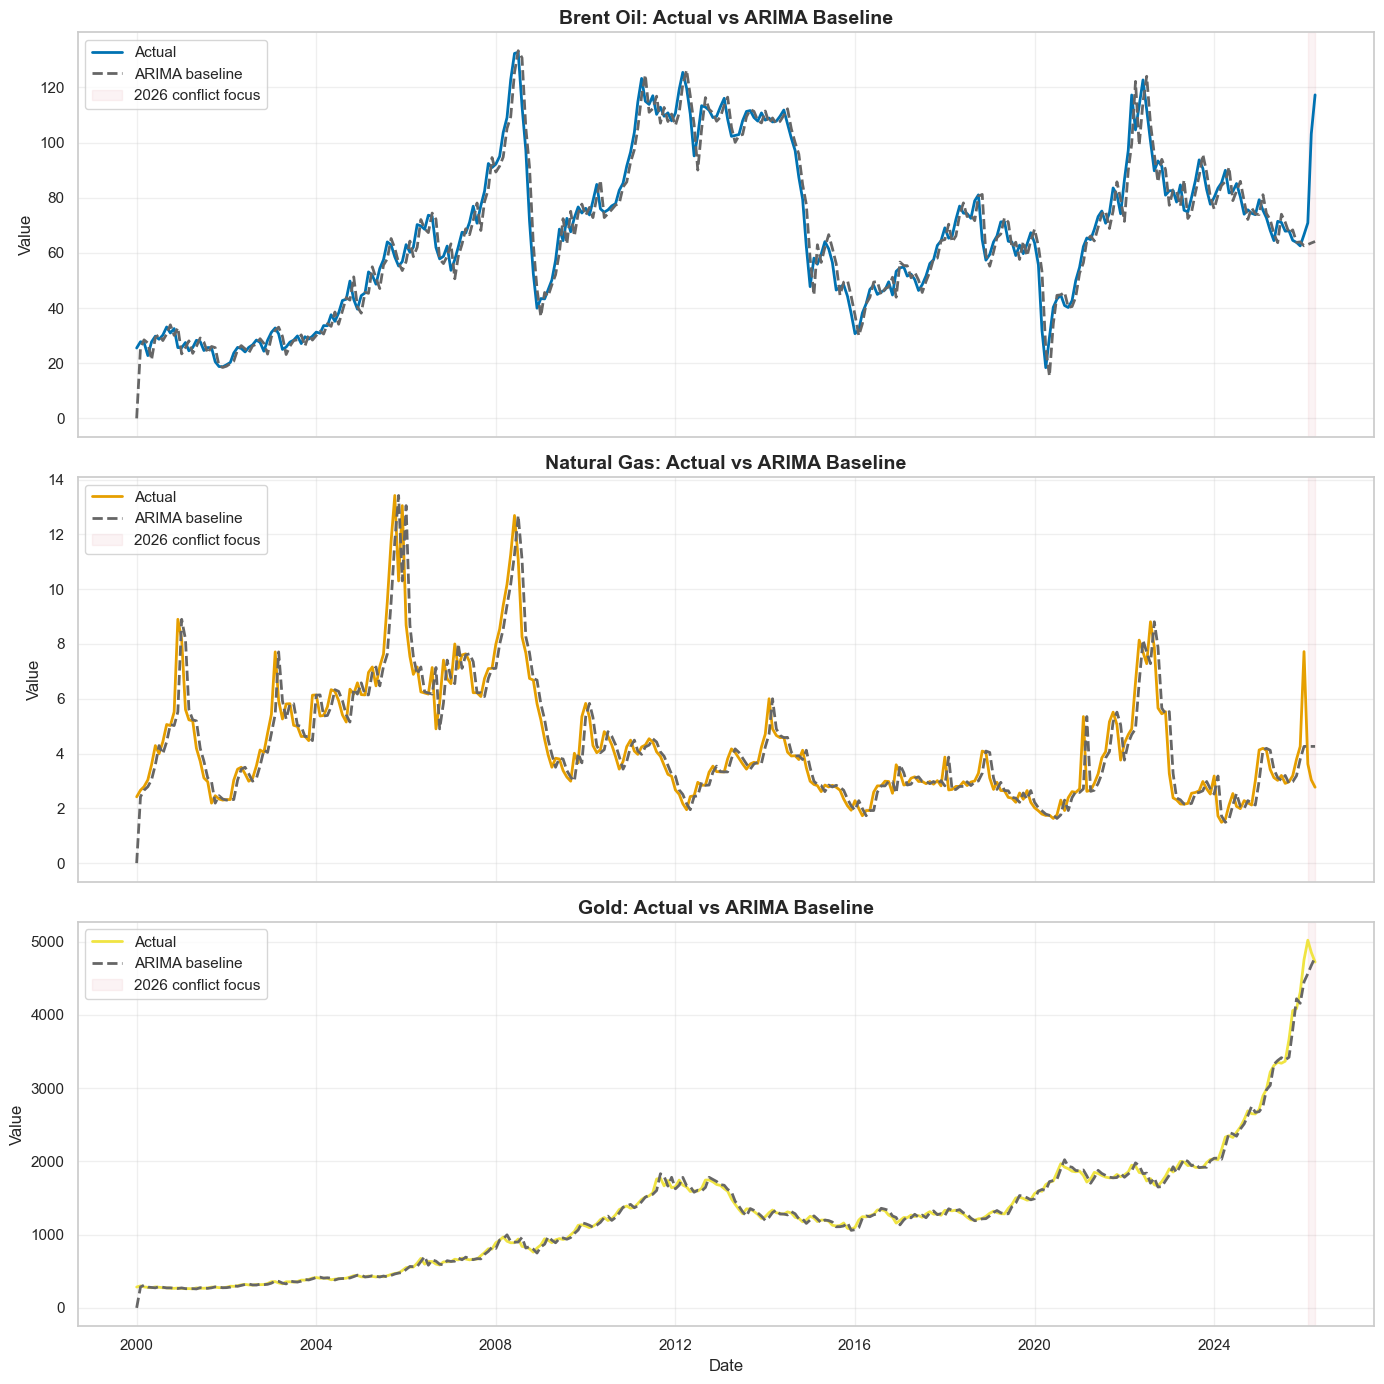

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
arima_actual_prediction_pairs = [
    ('brent_price', 'brent_arima_prediction', 'Brent Oil: Actual vs ARIMA Baseline'),
    ('gas_price', 'gas_arima_prediction', 'Natural Gas: Actual vs ARIMA Baseline'),
    ('gold_price', 'gold_arima_prediction', 'Gold: Actual vs ARIMA Baseline'),
]

for axis, (actual_column, prediction_column, title) in zip(axes, arima_actual_prediction_pairs):
    axis.plot(arima_analysis_data['date'], arima_analysis_data[actual_column], label='Actual', linewidth=2, color=INDICATOR_COLOR_MAP[actual_column])
    axis.plot(arima_analysis_data['date'], arima_analysis_data[prediction_column], label='ARIMA baseline', linestyle='--', linewidth=2, color=COLOR_MAP['baseline'])
    axis.axvspan(CONFLICT_FOCUS_DATE, arima_analysis_data['date'].max(), color=COLOR_MAP['conflict'], alpha=0.08, label='2026 conflict focus')
    axis.set_title(title, fontsize=14, fontweight='bold')
    axis.set_ylabel('Value')
    axis.grid(alpha=0.3)
    axis.legend(loc='upper left')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'actual_vs_predicted_arima.png', dpi=300, bbox_inches='tight')
plt.show()

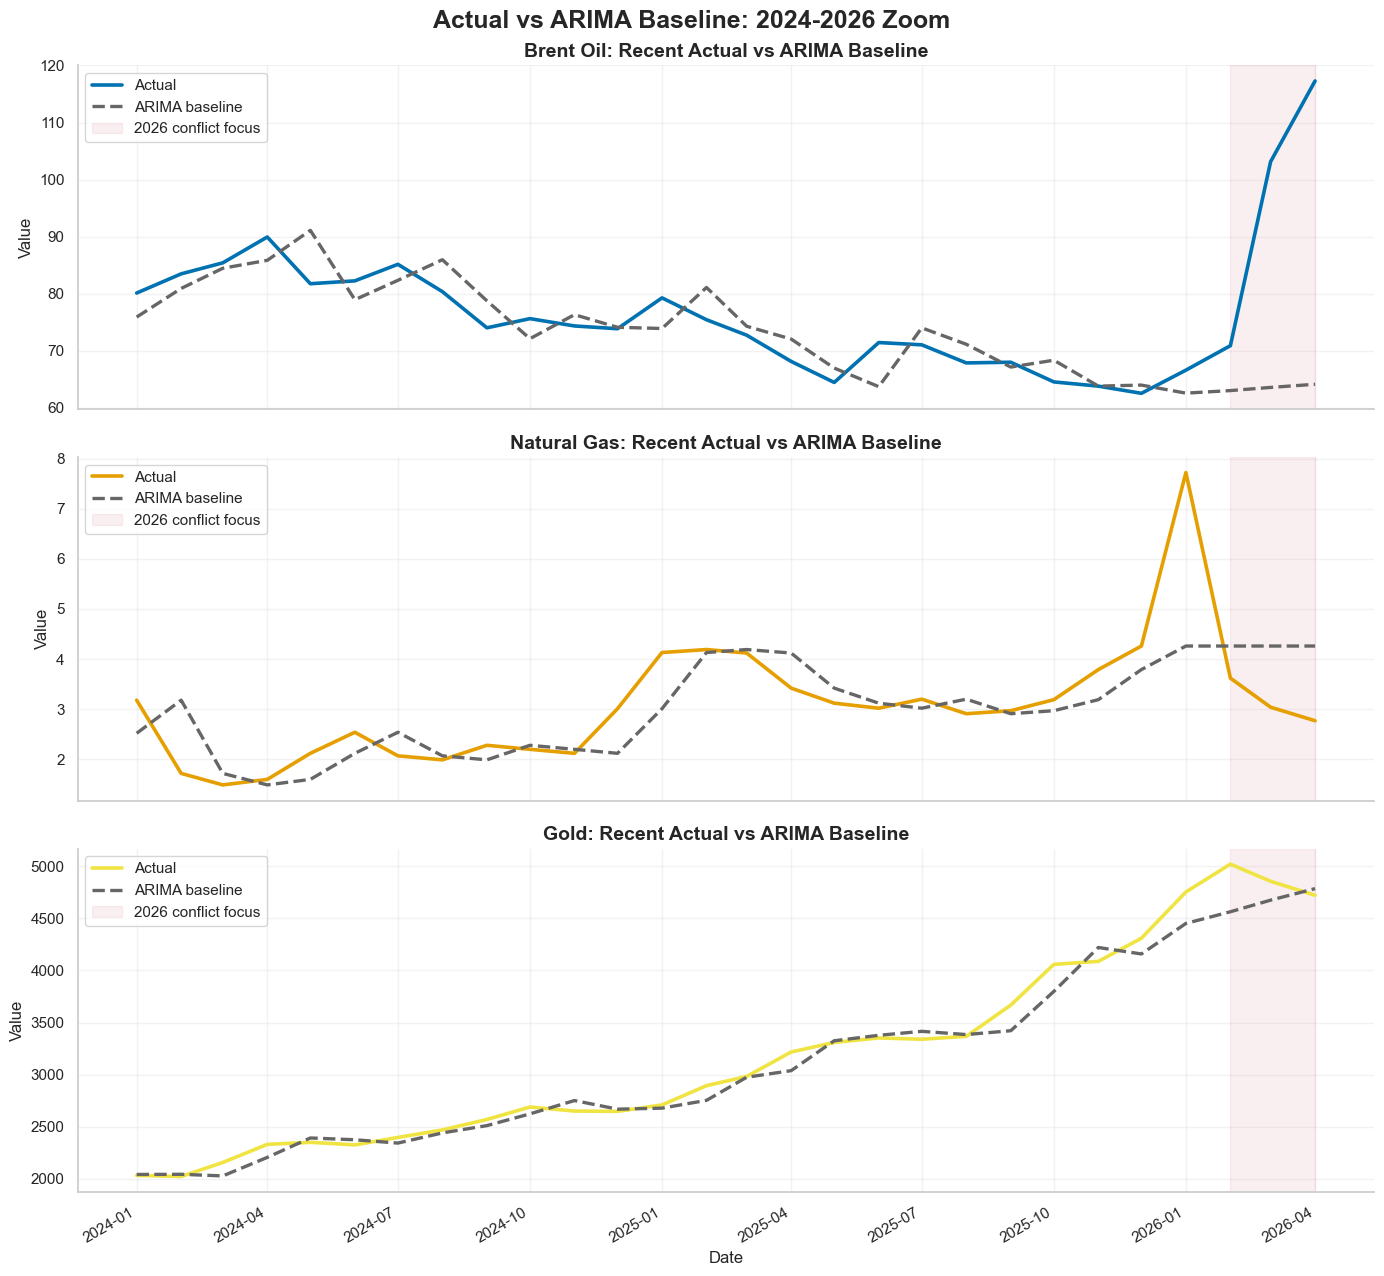

In [28]:
arima_zoom_prediction_data = arima_analysis_data[
    (arima_analysis_data['date'] >= ZOOM_START_DATE) &
    (arima_analysis_data['date'] <= ZOOM_END_DATE)
].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
arima_zoom_actual_prediction_pairs = [
    ('brent_price', 'brent_arima_prediction', 'Brent Oil: Recent Actual vs ARIMA Baseline'),
    ('gas_price', 'gas_arima_prediction', 'Natural Gas: Recent Actual vs ARIMA Baseline'),
    ('gold_price', 'gold_arima_prediction', 'Gold: Recent Actual vs ARIMA Baseline'),
]

for axis, (actual_column, prediction_column, title) in zip(axes, arima_zoom_actual_prediction_pairs):
    axis.plot(arima_zoom_prediction_data['date'], arima_zoom_prediction_data[actual_column], label='Actual', linewidth=2.6, color=INDICATOR_COLOR_MAP[actual_column])
    axis.plot(arima_zoom_prediction_data['date'], arima_zoom_prediction_data[prediction_column], label='ARIMA baseline', linestyle='--', linewidth=2.4, color=COLOR_MAP['baseline'])
    axis.axvspan(CONFLICT_FOCUS_DATE, arima_zoom_prediction_data['date'].max(), color=COLOR_MAP['conflict'], alpha=0.10, label='2026 conflict focus')
    axis.set_title(title, fontsize=14, fontweight='bold')
    axis.set_ylabel('Value')
    axis.grid(alpha=0.25)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.legend(loc='upper left', frameon=True)

axes[-1].set_xlabel('Date')
fig.suptitle('Actual vs ARIMA Baseline: 2024-2026 Zoom', fontsize=18, fontweight='bold')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'actual_vs_predicted_2024_2026_arima.png', dpi=300, bbox_inches='tight')
plt.show()

### 16.3 ARIMA Prediction Gap

Prediction gap dihitung dengan rumus `actual - ARIMA forecast`. Gap positif berarti harga aktual lebih tinggi dari forecast ARIMA, sehingga dapat dibaca sebagai indikasi pergerakan abnormal.

In [29]:
arima_commodity_columns = {
    'brent': ('brent_price', 'brent_arima_prediction'),
    'gas': ('gas_price', 'gas_arima_prediction'),
    'gold': ('gold_price', 'gold_arima_prediction'),
}

for commodity, (actual_column, prediction_column) in arima_commodity_columns.items():
    gap_column = f'{commodity}_arima_gap'
    gap_percent_column = f'{commodity}_arima_gap_percent'

    arima_analysis_data[gap_column] = arima_analysis_data[actual_column] - arima_analysis_data[prediction_column]
    arima_analysis_data[gap_percent_column] = (arima_analysis_data[gap_column] / arima_analysis_data[prediction_column]) * 100

arima_shock_2026 = arima_analysis_data[arima_analysis_data['date'] >= ANALYSIS_START_DATE].copy()
arima_gap_columns = [
    'date',
    'brent_price', 'brent_arima_prediction', 'brent_arima_gap', 'brent_arima_gap_percent',
    'gas_price', 'gas_arima_prediction', 'gas_arima_gap', 'gas_arima_gap_percent',
    'gold_price', 'gold_arima_prediction', 'gold_arima_gap', 'gold_arima_gap_percent',
    'cci', 'cci_change_percent',
]
display(arima_shock_2026[arima_gap_columns])

,date,brent_price,brent_arima_prediction,brent_arima_gap,brent_arima_gap_percent,gas_price,gas_arima_prediction,gas_arima_gap,gas_arima_gap_percent,gold_price,gold_arima_prediction,gold_arima_gap,gold_arima_gap_percent,cci,cci_change_percent
312,2026-01-01,66.60,62.57,4.03,6.43,7.72,4.26,3.46,81.22,"4,752.75","4,451.02",301.73,6.78,101.06,-0.03
313,2026-02-01,70.89,63.02,7.87,12.49,3.62,4.26,-0.64,-15.02,"5,019.97","4,563.06",456.91,10.01,100.93,-0.13
314,2026-03-01,103.13,63.57,39.56,62.22,3.04,4.26,-1.22,-28.64,"4,855.54","4,674.42",181.12,3.87,100.73,-0.20
315,2026-04-01,117.29,64.13,53.16,82.90,2.77,4.26,-1.49,-34.98,"4,721.42","4,785.10",-63.68,-1.33,100.52,-0.22


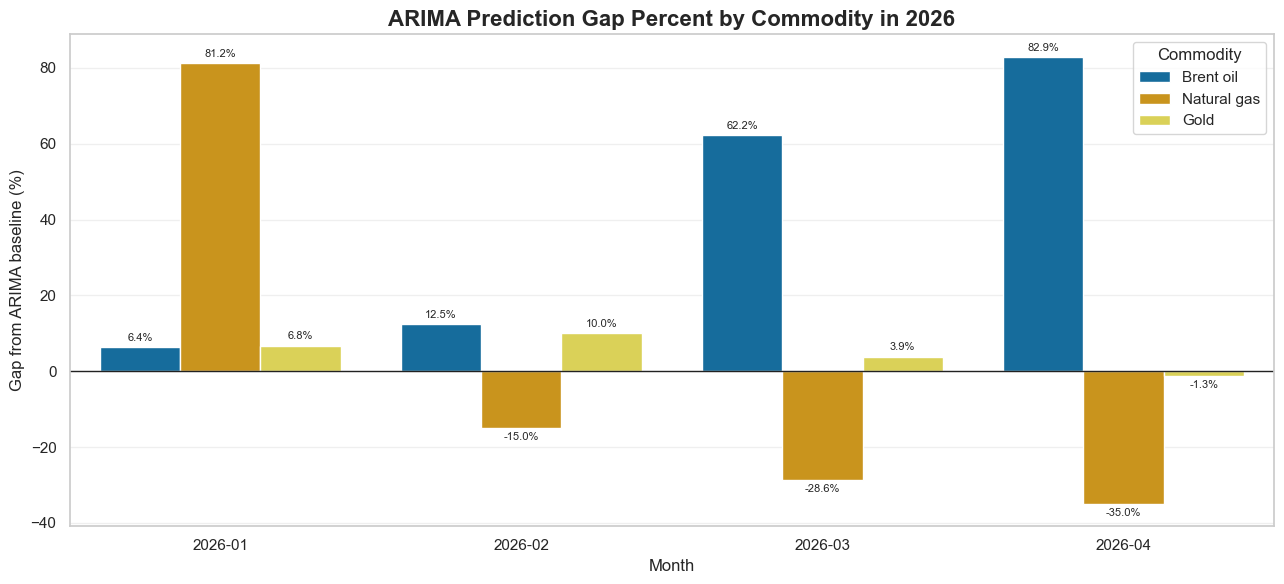

In [30]:
arima_gap_plot_data = arima_shock_2026[
    ['date', 'brent_arima_gap_percent', 'gas_arima_gap_percent', 'gold_arima_gap_percent']
].melt(
    id_vars='date',
    value_name='gap_percent',
    var_name='commodity',
)
arima_gap_plot_data['commodity'] = arima_gap_plot_data['commodity'].map({
    'brent_arima_gap_percent': 'Brent oil',
    'gas_arima_gap_percent': 'Natural gas',
    'gold_arima_gap_percent': 'Gold',
})
arima_gap_plot_data['date'] = arima_gap_plot_data['date'].dt.strftime('%Y-%m')


plt.figure(figsize=(13, 6))
ax = sns.barplot(data=arima_gap_plot_data, x='date', y='gap_percent', hue='commodity', palette=GAP_COLOR_MAP)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8)

plt.axhline(0, color=COLOR_MAP['zero'], linewidth=1)
plt.title('ARIMA Prediction Gap Percent by Commodity in 2026', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Gap from ARIMA baseline (%)')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Commodity')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'prediction_gap_percent_arima.png', dpi=300, bbox_inches='tight')
plt.show()

### 16.4 ARIMA Global Commodity Shock Index

Indeks shock ARIMA dihitung dari rata-rata gap percentage Brent oil, natural gas, dan gold. Nilai ini digunakan untuk melihat tekanan komoditas global selama 2026 secara ringkas.

In [31]:
arima_gap_percent_columns = [
    'brent_arima_gap_percent',
    'gas_arima_gap_percent',
    'gold_arima_gap_percent',
]
arima_analysis_data['global_arima_shock_index'] = arima_analysis_data[arima_gap_percent_columns].mean(axis=1)
arima_analysis_data['brent_only_arima_shock_index'] = arima_analysis_data['brent_arima_gap_percent']
arima_shock_2026 = arima_analysis_data[arima_analysis_data['date'] >= ANALYSIS_START_DATE].copy()

display(arima_shock_2026[[
    'date',
    'brent_arima_gap_percent',
    'gas_arima_gap_percent',
    'gold_arima_gap_percent',
    'global_arima_shock_index',
    'brent_only_arima_shock_index',
    'cci_change_percent',
]])

,date,brent_arima_gap_percent,gas_arima_gap_percent,gold_arima_gap_percent,global_arima_shock_index,brent_only_arima_shock_index,cci_change_percent
312,2026-01-01,6.43,81.22,6.78,31.48,6.43,-0.03
313,2026-02-01,12.49,-15.02,10.01,2.49,12.49,-0.13
314,2026-03-01,62.22,-28.64,3.87,12.49,62.22,-0.20
315,2026-04-01,82.90,-34.98,-1.33,15.53,82.90,-0.22


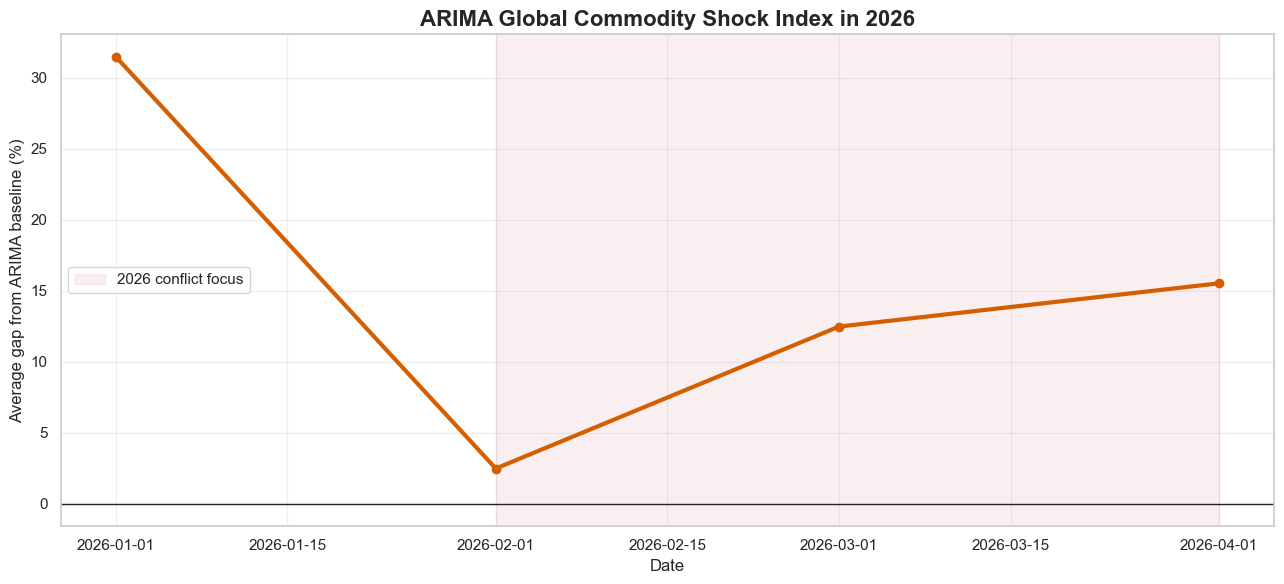

In [32]:
plt.figure(figsize=(13, 6))
plt.plot(arima_shock_2026['date'], arima_shock_2026['global_arima_shock_index'], marker='o', linewidth=3, color=COLOR_MAP['shock'])
plt.axhline(0, color=COLOR_MAP['zero'], linewidth=1)
plt.axvspan(CONFLICT_FOCUS_DATE, arima_shock_2026['date'].max(), color=COLOR_MAP['conflict'], alpha=0.10, label='2026 conflict focus')
plt.title('ARIMA Global Commodity Shock Index in 2026', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average gap from ARIMA baseline (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'global_commodity_shock_index_arima.png', dpi=300, bbox_inches='tight')
plt.show()

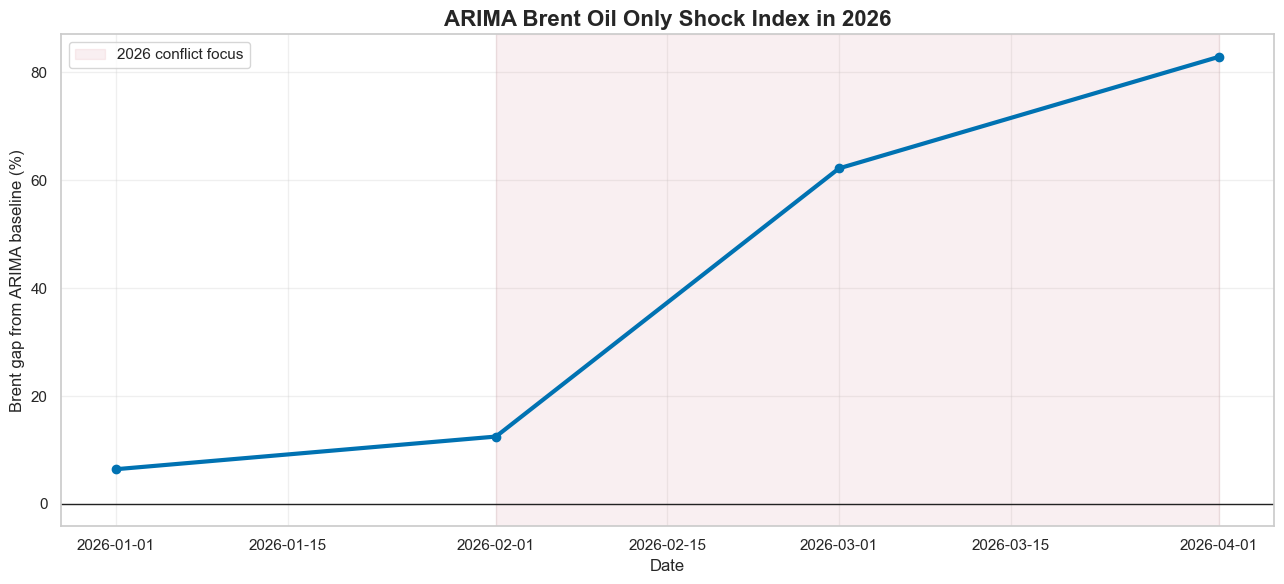

In [33]:
plt.figure(figsize=(13, 6))
plt.plot(arima_shock_2026['date'], arima_shock_2026['brent_only_arima_shock_index'], marker='o', linewidth=3, color=COLOR_MAP['brent'])
plt.axhline(0, color=COLOR_MAP['zero'], linewidth=1)
plt.axvspan(CONFLICT_FOCUS_DATE, arima_shock_2026['date'].max(), color=COLOR_MAP['conflict'], alpha=0.10, label='2026 conflict focus')
plt.title('ARIMA Brent Oil Only Shock Index in 2026', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Brent gap from ARIMA baseline (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'brent_only_shock_index_arima.png', dpi=300, bbox_inches='tight')
plt.show()

### 16.5 Save ARIMA Outputs

Output ARIMA disimpan terpisah dengan suffix `_arima`. Hal ini membuat hasil model time series mudah dibedakan dari output Linear Regression.

In [34]:
arima_output_columns = [
    'date',
    'brent_price', 'gas_price', 'gold_price', 'cci',
    'month_index', 'year', 'month',
    'brent_change_percent', 'gas_change_percent', 'gold_change_percent', 'cci_change_percent',
    'brent_arima_prediction', 'gas_arima_prediction', 'gold_arima_prediction',
    'brent_arima_gap', 'gas_arima_gap', 'gold_arima_gap',
    'brent_arima_gap_percent', 'gas_arima_gap_percent', 'gold_arima_gap_percent',
    'global_arima_shock_index', 'brent_only_arima_shock_index',
]

arima_output_data = arima_analysis_data[arima_output_columns].copy()
arima_shock_output_data = arima_shock_2026[arima_output_columns].copy()

arima_processed_data_path = PROCESSED_DATA_DIR / 'merged_commodity_cci_data_arima.csv'
arima_output_data_path = OUTPUTS_DIR / 'merged_commodity_cci_data_arima.csv'
arima_shock_output_path = OUTPUTS_DIR / 'shock_gap_2026_arima.csv'

arima_output_data.to_csv(arima_processed_data_path, index=False)
arima_output_data.to_csv(arima_output_data_path, index=False)
arima_shock_output_data.to_csv(arima_shock_output_path, index=False)

print(f'Saved ARIMA processed data to {arima_processed_data_path}')
print(f'Saved ARIMA merged output data to {arima_output_data_path}')
print(f'Saved ARIMA 2026 shock gap data to {arima_shock_output_path}')

Saved ARIMA processed data to data/processed/merged_commodity_cci_data_arima.csv
Saved ARIMA merged output data to outputs/merged_commodity_cci_data_arima.csv
Saved ARIMA 2026 shock gap data to outputs/shock_gap_2026_arima.csv


### 16.6 Ringkasan Hasil ARIMA

Ringkasan ini menjelaskan hasil utama dari model ARIMA. Interpretasi tetap hati-hati karena prediction gap tidak membuktikan hubungan sebab-akibat langsung.

In [35]:
if not arima_shock_2026.empty:
    highest_arima_shock_row = arima_shock_2026.loc[arima_shock_2026['global_arima_shock_index'].idxmax()]
    highest_arima_shock_month = highest_arima_shock_row['date'].strftime('%Y-%m')
    highest_arima_shock_value = highest_arima_shock_row['global_arima_shock_index']

    average_arima_shock_index = arima_shock_2026['global_arima_shock_index'].mean()
    latest_arima_month = arima_shock_2026['date'].max().strftime('%Y-%m')
else:
    highest_arima_shock_month = 'tidak tersedia'
    highest_arima_shock_value = np.nan
    average_arima_shock_index = np.nan
    latest_arima_month = 'tidak tersedia'

arima_insight_lines = [
    'Ringkasan Hasil ARIMA:',
    f'- ARIMA dilatih menggunakan data bulanan sampai {TRAIN_END_DATE.strftime("%Y-%m")} dan digunakan untuk forecast periode 2026.',
    '- Order ARIMA dipilih terpisah untuk setiap komoditas berdasarkan nilai AIC terkecil.',
    f'- ARIMA Global Commodity Shock Index tertinggi terjadi pada {highest_arima_shock_month}, sebesar {highest_arima_shock_value:.2f}%.',
    f'- Rata-rata ARIMA Global Commodity Shock Index sampai {latest_arima_month} adalah {average_arima_shock_index:.2f}%.',
    '- Gap positif berarti harga aktual lebih tinggi dari ARIMA forecast.',
    '- Prediction gap menunjukkan pergerakan abnormal terhadap baseline, bukan bukti kausalitas langsung dari konflik.',
]

for line in arima_insight_lines:
    print(line)

with open(OUTPUTS_DIR / 'insight_summary_arima.txt', 'w', encoding='utf-8') as file:
    file.write('\n'.join(arima_insight_lines))


Ringkasan Hasil ARIMA:
- ARIMA dilatih menggunakan data bulanan sampai 2025-12 dan digunakan untuk forecast periode 2026.
- Order ARIMA dipilih terpisah untuk setiap komoditas berdasarkan nilai AIC terkecil.
- ARIMA Global Commodity Shock Index tertinggi terjadi pada 2026-01, sebesar 31.48%.
- Rata-rata ARIMA Global Commodity Shock Index sampai 2026-04 adalah 15.50%.
- Gap positif berarti harga aktual lebih tinggi dari ARIMA forecast.
- Prediction gap menunjukkan pergerakan abnormal terhadap baseline, bukan bukti kausalitas langsung dari konflik.
